# Neural Ratio Estimation with PyMC Integration

This notebook demonstrates how to:

1. Train a BayesFlow `RatioApproximator` on a **2-parameter normal model** ($\mu$, $\sigma$)
2. Investigate the extracted function visually
3. Run **NUTS sampling** in PyMC (scalar-parameter case)
4. Demonstrate a **regression model** where $\mu$ varies per trial via covariates

## Part 1: Train the Ratio Estimator

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm

from bayesflow.wrappers.pymc import NeuralRatioDistribution

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
INFO:arviz:Found 'auto' as default backend, checking available backends
INFO:arviz:Matplotlib is available, defining as default backend
INFO:arviz.preview:arviz_base available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_stats available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_plots available, exposing its functions as part of arviz.preview


### Generative Model

We use a 2-parameter normal model:
$$x \mid \mu, \sigma \sim \mathcal{N}(\mu, \sigma^2)$$

with priors $\mu \sim \text{Uniform}(-5, 5)$ and $\sigma \sim \text{Uniform}(0.5, 3.0)$.

The ratio estimator learns the **single-observation** log-ratio
$\log r(\mu, \sigma, x) = \log \frac{p(x \mid \mu, \sigma)}{p(x)}$,
which factorizes across i.i.d. observations:
$\log r(\mu, \sigma, x_{1:n}) = \sum_{i=1}^{n} \log r(\mu, \sigma, x_i)$.

In [2]:
def prior():
    mu = np.random.uniform(-5, 5)
    sigma = np.random.uniform(0.5, 3.0)
    return {"mu": mu, "sigma": sigma}

def likelihood(mu, sigma):
    return {"x": mu + sigma * np.random.standard_normal()}

In [3]:
simulator = bf.make_simulator([prior, likelihood])

# Quick test
test_sims = simulator.sample(3)
for k, v in test_sims.items():
    print(k, v.shape)

mu (3, 1)
sigma (3, 1)
x (3, 1)


### Build Adapter & Train

In [4]:
adapter = bf.RatioApproximator.build_adapter(
    inference_variables=["mu", "sigma"],
    inference_conditions=["x"]
)

ratio_approximator = bf.RatioApproximator(
    adapter=adapter,
    inference_network=bf.networks.MLP(widths=[128, 128, 128]),
    standardize=None
)

In [5]:
ratio_approximator.compile(optimizer="adam")

history = ratio_approximator.fit(
    simulator=simulator,
    epochs=50,
    num_batches=200,
    batch_size=64,
)

INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 24 data loading workers.


INFO:bayesflow:Building on a test batch.


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.5797
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2470
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2197
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1975
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1972
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2022
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1845
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1822
Epoch 9/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1811
Epoch 10/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1759
Epoch 11/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1791
Epoch 12/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1797
Epoch 13/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1731
Epoch 14/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1794
Epoch 15/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

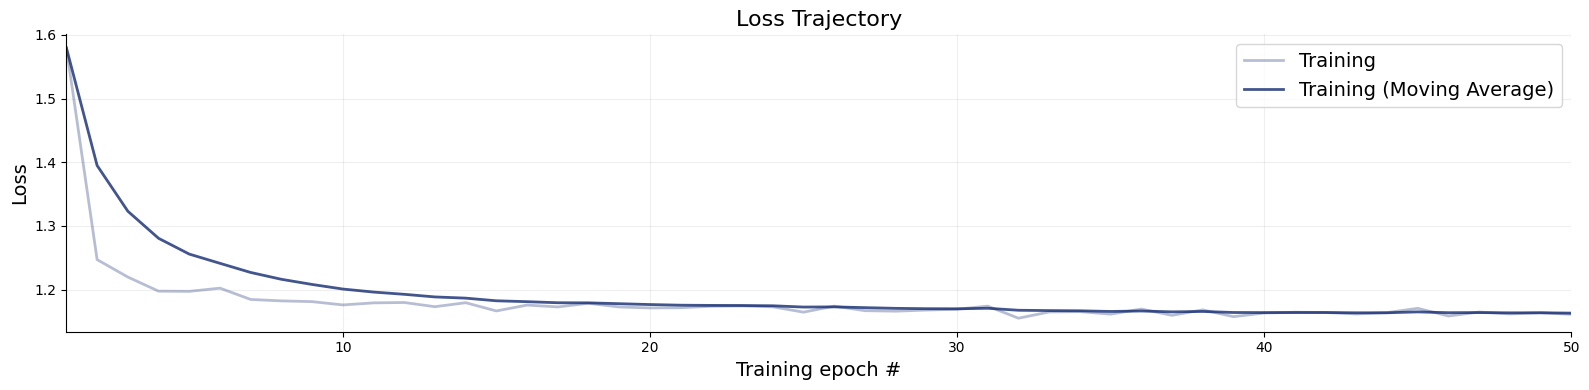

In [6]:
f = bf.diagnostics.plots.loss(history)

---
## Part 2: Investigate the Single-Trial Log-Ratio

Before plugging into an MCMC workflow, we want to make sure:
1. The extracted JAX function matches the original `ratio_approximator.log_ratio()` output
2. The log-ratio landscape is sensible when plotted against the analytic log-likelihood

In [7]:
ratio_dist = NeuralRatioDistribution(
    ratio_approximator=ratio_approximator,
    param_names=["mu", "sigma"],
    exchangeable=True
)

### Consistency Check: Extracted vs. Original

In [8]:
import jax
import jax.numpy as jnp

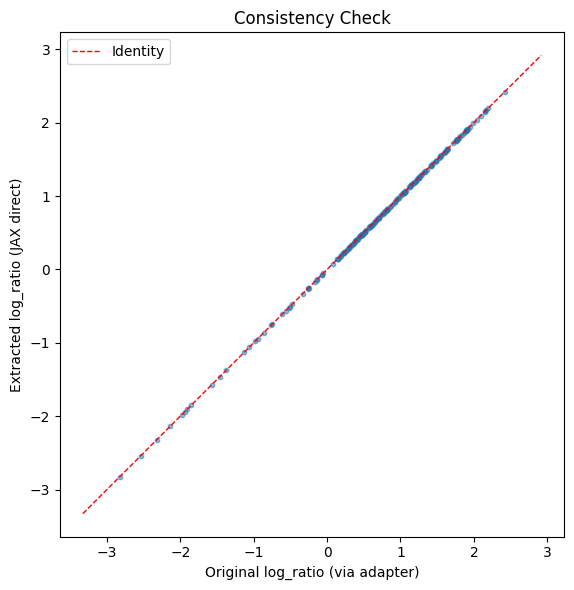

Max absolute difference: 0.00e+00


In [9]:
# Generate test data
n_test = 200
test_data = simulator.sample(n_test)

# Original path: through the adapter
original_lr = keras.ops.convert_to_numpy(ratio_approximator.log_ratio(test_data)).flatten()

# Extracted path: call the JAX function directly via vmap
vmap_fn = jax.vmap(ratio_dist.backend.log_ratio)
extracted_lr = np.asarray(vmap_fn(
    jnp.array(test_data["x"].flatten()),
    jnp.array(test_data["mu"].flatten()),
    jnp.array(test_data["sigma"].flatten()),
)).flatten()

f, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(original_lr, extracted_lr, alpha=0.5, s=10)
lims = [min(original_lr.min(), extracted_lr.min()) - 0.5, max(original_lr.max(), extracted_lr.max()) + 0.5]
ax.plot(lims, lims, 'r--', lw=1, label='Identity')
ax.set_xlabel("Original log_ratio (via adapter)")
ax.set_ylabel("Extracted log_ratio (JAX direct)")
ax.set_title("Consistency Check")
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(original_lr - extracted_lr))
print(f"Max absolute difference: {max_diff:.2e}")

### Log-Ratio Landscape: 2D Heatmap

We fix a single observation $x_{obs} = 2.0$ and plot the log-ratio as a function of
$(\mu, \sigma)$. We also overlay the analytic log-likelihood $\log \mathcal{N}(x_{obs} \mid \mu, \sigma)$.
The two should match up to a constant offset (the log evidence).

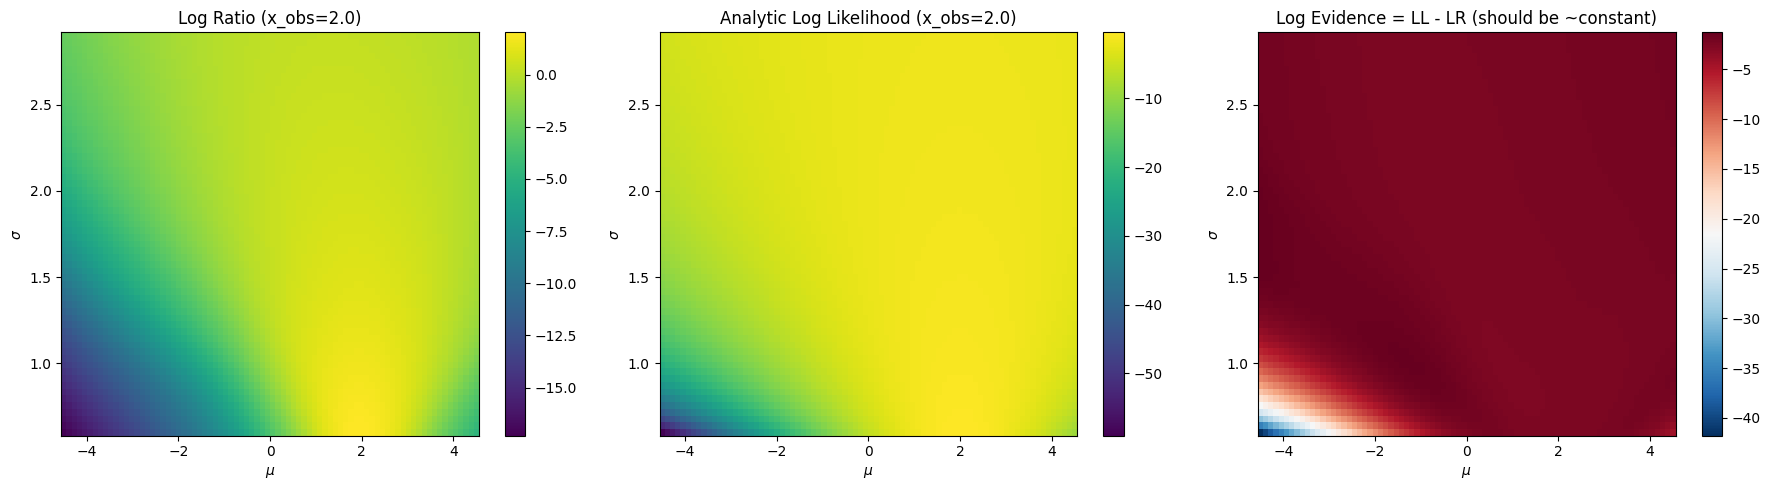

In [10]:
x_obs_val = 2.0
mu_grid = np.linspace(-4.5, 4.5, 80)
sigma_grid = np.linspace(0.6, 2.9, 60)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

# Flatten for vmap
mu_flat = jnp.array(MU.flatten())
sigma_flat = jnp.array(SIGMA.flatten())
x_flat = jnp.full_like(mu_flat, x_obs_val)

# Evaluate extracted log-ratio
vmap_fn_all = jax.vmap(ratio_dist.backend.log_ratio, in_axes=(0, 0, 0))
lr_flat = np.asarray(vmap_fn_all(x_flat, mu_flat, sigma_flat))
LR = lr_flat.reshape(MU.shape)

# Analytic log-likelihood
LL = sp_norm.logpdf(x_obs_val, loc=MU, scale=SIGMA)

# Log evidence = log_lik - log_ratio (should be ~constant where well-calibrated)
LE = LL - LR

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(MU, SIGMA, LR, shading='auto', cmap='viridis')
axes[0].set_title(f"Log Ratio (x_obs={x_obs_val})")
axes[0].set_xlabel("$\\mu$")
axes[0].set_ylabel("$\\sigma$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(MU, SIGMA, LL, shading='auto', cmap='viridis')
axes[1].set_title(f"Analytic Log Likelihood (x_obs={x_obs_val})")
axes[1].set_xlabel("$\\mu$")
axes[1].set_ylabel("$\\sigma$")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(MU, SIGMA, LE, shading='auto', cmap='RdBu_r')
axes[2].set_title(f"Log Evidence = LL - LR (should be ~constant)")
axes[2].set_xlabel("$\\mu$")
axes[2].set_ylabel("$\\sigma$")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()

### Log-Ratio vs. $\mu$ for Fixed $\sigma$ Slices

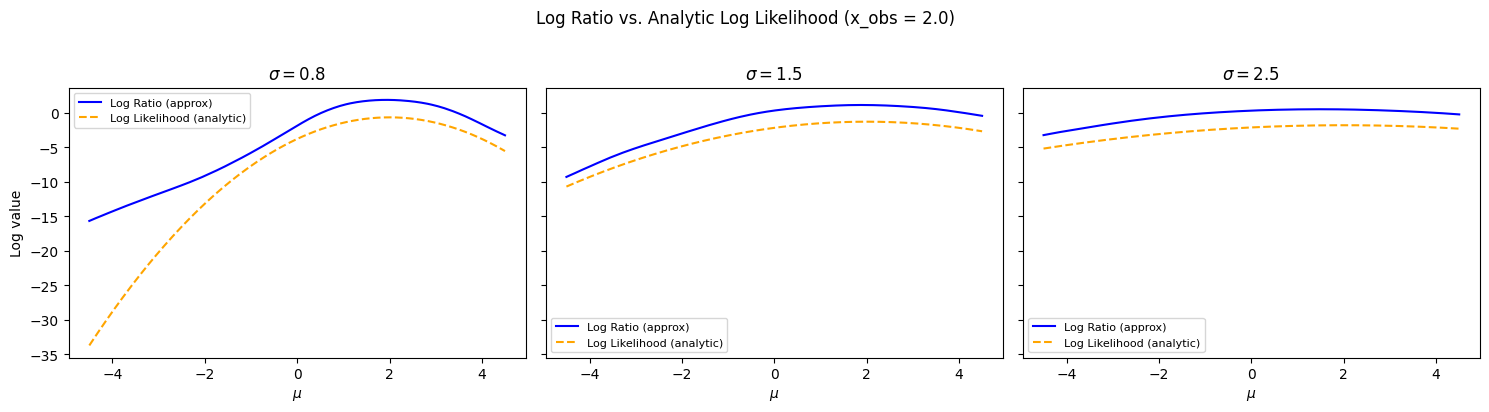

In [11]:
sigma_slices = [0.8, 1.5, 2.5]
mu_vals = np.linspace(-4.5, 4.5, 200)

fig, axes = plt.subplots(1, len(sigma_slices), figsize=(5 * len(sigma_slices), 4), sharey=True)

for i, sig_val in enumerate(sigma_slices):
    mu_j = jnp.array(mu_vals)
    sig_j = jnp.full_like(mu_j, sig_val)
    x_j = jnp.full_like(mu_j, x_obs_val)
    
    lr_vals = np.asarray(vmap_fn_all(x_j, mu_j, sig_j))
    ll_vals = sp_norm.logpdf(x_obs_val, loc=mu_vals, scale=sig_val)
    
    ax = axes[i]
    ax.plot(mu_vals, lr_vals, label="Log Ratio (approx)", color="blue")
    ax.plot(mu_vals, ll_vals, label="Log Likelihood (analytic)", color="orange", linestyle="--")
    ax.set_title(f"$\\sigma = {sig_val}$")
    ax.set_xlabel("$\\mu$")
    if i == 0:
        ax.set_ylabel("Log value")
    ax.legend(fontsize=8)

plt.suptitle(f"Log Ratio vs. Analytic Log Likelihood (x_obs = {x_obs_val})", y=1.02)
plt.tight_layout()
plt.show()

---
## Part 3: PyMC Model with NUTS (Scalar Parameters)

Both $\mu$ and $\sigma$ are scalar (same value for all trials). We simulate observed data
from the true model and recover the parameters using NUTS.

In [12]:
import pymc as pm
import pytensor
import arviz as az

In [13]:
# Ground truth parameters
mu_true = 2.0
sigma_true = 1.5
n_obs = 50

# Simulate observed data
np.random.seed(42)
x_observed = np.random.normal(loc=mu_true, scale=sigma_true, size=n_obs).astype(np.float32)

print(f"Observed data: n={n_obs}, mean={x_observed.mean():.3f}, std={x_observed.std():.3f}")
print(f"True: mu={mu_true}, sigma={sigma_true}")

Observed data: n=50, mean=1.662, std=1.386
True: mu=2.0, sigma=1.5


In [14]:
pytensor.config.floatX = keras.backend.floatx()

with pm.Model() as scalar_model:
    mu = pm.TruncatedNormal("mu", mu=0, sigma=5, lower=-5, upper=5)
    sigma = pm.TruncatedNormal("sigma", mu=1.5, sigma=1.5, lower=0.5, upper=3.0)

    obs = ratio_dist("obs", mu=mu, sigma=sigma, observed=x_observed)

    trace = pm.sample(
        draws=1000,
        tune=1000,
        nuts_sampler="pymc",
        chains=4,
        cores=1,
        random_seed=42,
        initvals={"mu": 0.0, "sigma": 1.5},
    )

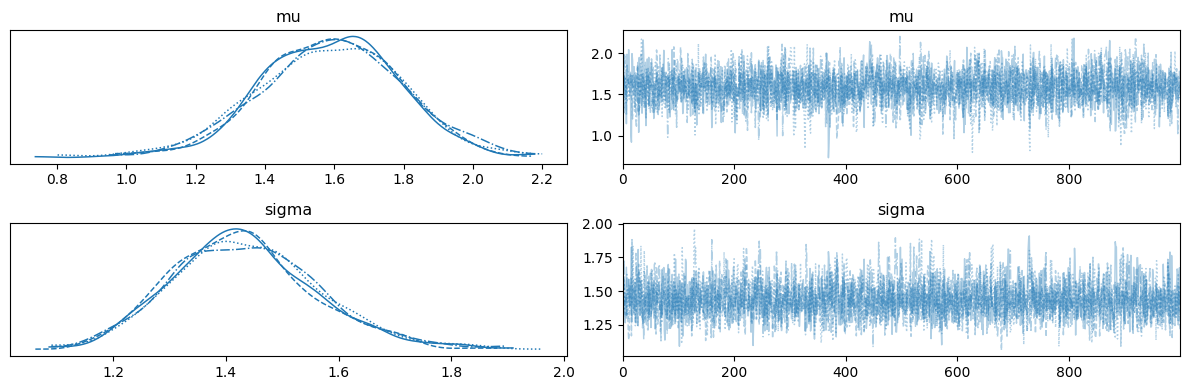

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu     1.588  0.203   1.231    1.988      0.003    0.004    3536.0    2736.0   
sigma  1.435  0.132   1.194    1.683      0.002    0.002    3421.0    2657.0   

       r_hat  
mu       1.0  
sigma    1.0  

True values: mu=2.0, sigma=1.5


In [15]:
az.plot_trace(trace, var_names=["mu", "sigma"])
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["mu", "sigma"]))
print(f"\nTrue values: mu={mu_true}, sigma={sigma_true}")

### Visualize Approximate Posteriors

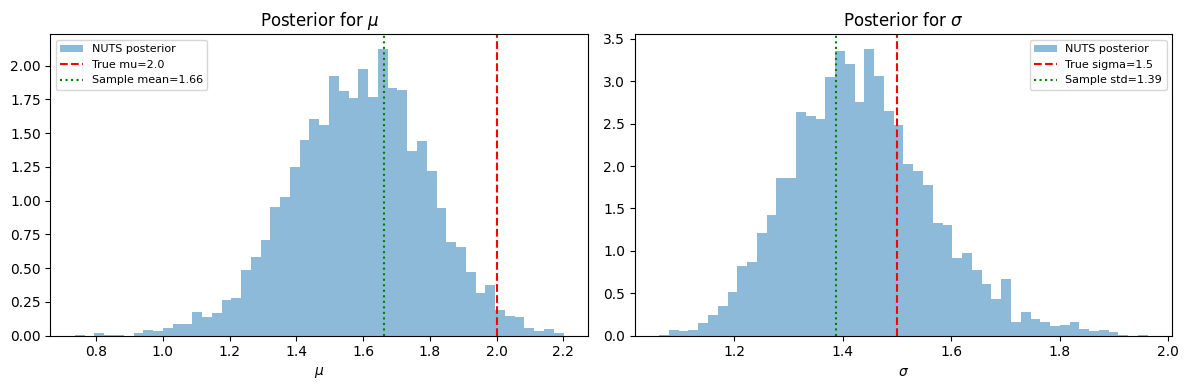

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Posterior for mu
mu_samples = trace.posterior["mu"].values.flatten()
axes[0].hist(mu_samples, bins=50, density=True, alpha=0.5, label="NUTS posterior")
axes[0].axvline(mu_true, color='r', linestyle='--', label=f'True mu={mu_true}')
axes[0].axvline(x_observed.mean(), color='g', linestyle=':', label=f'Sample mean={x_observed.mean():.2f}')
axes[0].set_xlabel("$\\mu$")
axes[0].set_title("Posterior for $\\mu$")
axes[0].legend(fontsize=8)

# Posterior for sigma
sigma_samples = trace.posterior["sigma"].values.flatten()
axes[1].hist(sigma_samples, bins=50, density=True, alpha=0.5, label="NUTS posterior")
axes[1].axvline(sigma_true, color='r', linestyle='--', label=f'True sigma={sigma_true}')
axes[1].axvline(x_observed.std(), color='g', linestyle=':', label=f'Sample std={x_observed.std():.2f}')
axes[1].set_xlabel("$\\sigma$")
axes[1].set_title("Posterior for $\\sigma$")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Part 4: PyMC Model with NUTS (Scalar Parameters)

Both $\mu$ and $\sigma$ are scalar (same value for all trials). We simulate observed data
from the true model and recover the parameters using NUTS.

### Generate Regression Data

We simulate data where $\mu_i = \beta_0 + \beta_1 \cdot \text{condition}_i$
and $\sigma$ is constant across trials.

In [17]:
# True regression parameters
beta_0_true = 1.0
beta_1_true = 2.0
sigma_reg_true = 1.0
n_obs_reg = 100

np.random.seed(123)

# Binary condition: 0 or 1
condition_data = np.random.choice([0, 1], size=n_obs_reg).astype(np.float32)

# Per-trial mu
mu_per_trial = beta_0_true + beta_1_true * condition_data

# Simulate observations
x_reg_observed = np.random.normal(loc=mu_per_trial, scale=sigma_reg_true).astype(np.float32)

print(f"n_obs: {n_obs_reg}")
print(f"Condition counts: 0->{(condition_data==0).sum()}, 1->{(condition_data==1).sum()}")
print(f"True: beta_0={beta_0_true}, beta_1={beta_1_true}, sigma={sigma_reg_true}")

n_obs: 100
Condition counts: 0->55, 1->45
True: beta_0=1.0, beta_1=2.0, sigma=1.0


### Build PyMC Regression Model

In [19]:
with pm.Model() as regression_model:
    # --- Truncated priors that respect the training data regime ---
    # mu_i = beta_0 + beta_1 * condition_i, and condition in {0,1}.
    # We need mu_i in [-5, 5] for every trial, so we constrain the betas
    # conservatively to keep their sum inside the training range.
    beta_0 = pm.TruncatedNormal("beta_0", mu=0, sigma=3, lower=-4, upper=4)
    beta_1 = pm.TruncatedNormal("beta_1", mu=0, sigma=3, lower=-4, upper=4)
    sigma = pm.TruncatedNormal(
        "sigma", mu=1.5, sigma=1.5, lower=0.5, upper=3.0
    )

    # mu is now a per-trial vector
    mu_reg = beta_0 + beta_1 * condition_data

    obs = ratio_dist("obs", mu=mu_reg, sigma=sigma, observed=x_reg_observed)

    trace_reg = pm.sample(
        draws=1000,
        nuts_sampler="pymc",
        cores=1,
        chains=4,
        tune=1000,
        random_seed=42,
        initvals={"beta_0": 0.0, "beta_1": 0.0, "sigma": 1.5},
    )

INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Sequential sampling (4 chains in 1 job)
INFO:pymc.sampling.mcmc:NUTS: [beta_0, beta_1, sigma]


Output()

INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta_0  1.057  0.145   0.781    1.322      0.003    0.002    2318.0    2522.0   
beta_1  1.920  0.205   1.526    2.300      0.004    0.003    2219.0    2331.0   
sigma   1.098  0.064   0.980    1.217      0.001    0.001    2157.0    2268.0   

        r_hat  
beta_0    1.0  
beta_1    1.0  
sigma     1.0  

True values: beta_0=1.0, beta_1=2.0, sigma=1.0


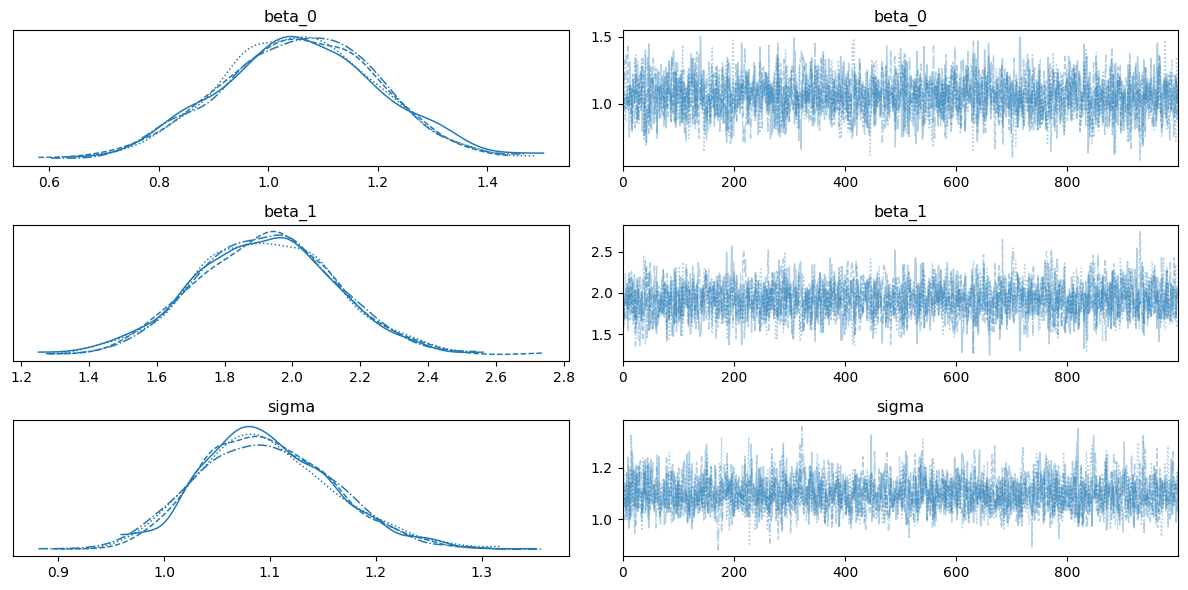

In [20]:
az.plot_trace(trace_reg, var_names=["beta_0", "beta_1", "sigma"])
plt.tight_layout()

print(az.summary(trace_reg, var_names=["beta_0", "beta_1", "sigma"]))
print(f"\nTrue values: beta_0={beta_0_true}, beta_1={beta_1_true}, sigma={sigma_reg_true}")

In [21]:
# Compare to simple OLS estimates
from numpy.linalg import lstsq

X_design = np.column_stack([np.ones(n_obs_reg), condition_data])
ols_coeffs, _, _, _ = lstsq(X_design, x_reg_observed, rcond=None)
ols_residuals = x_reg_observed - X_design @ ols_coeffs
ols_sigma = np.std(ols_residuals, ddof=2)

print(f"OLS estimates: beta_0={ols_coeffs[0]:.3f}, beta_1={ols_coeffs[1]:.3f}, sigma={ols_sigma:.3f}")
print(f"True values:   beta_0={beta_0_true}, beta_1={beta_1_true}, sigma={sigma_reg_true}")

OLS estimates: beta_0=1.181, beta_1=1.850, sigma=1.070
True values:   beta_0=1.0, beta_1=2.0, sigma=1.0


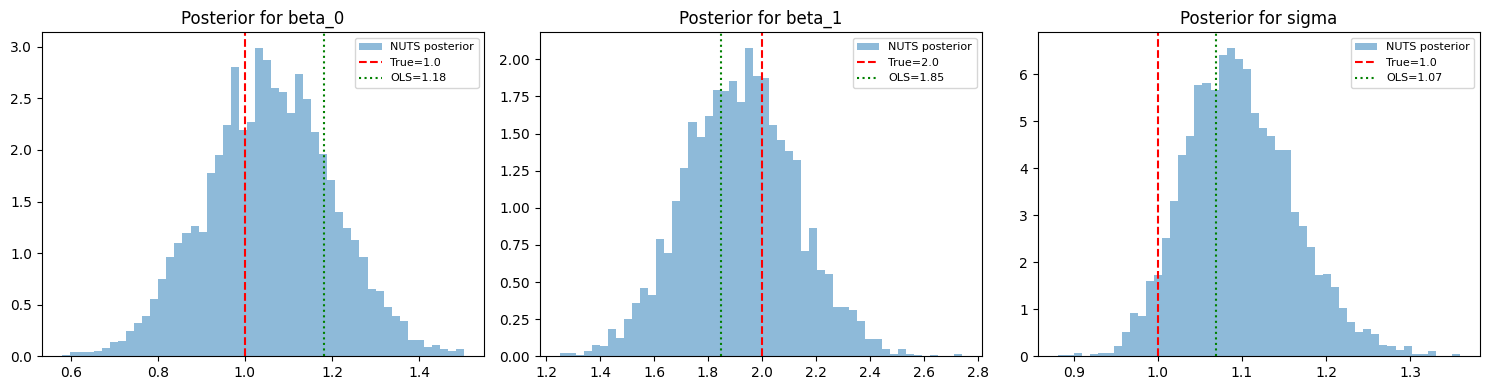

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, true_val) in enumerate([
    ("beta_0", beta_0_true),
    ("beta_1", beta_1_true),
    ("sigma", sigma_reg_true),
]):
    samples = trace_reg.posterior[name].values.flatten()
    axes[i].hist(samples, bins=50, density=True, alpha=0.5, label="NUTS posterior")
    axes[i].axvline(true_val, color='r', linestyle='--', label=f'True={true_val}')
    if name != "sigma":
        axes[i].axvline(ols_coeffs[i], color='g', linestyle=':', label=f'OLS={ols_coeffs[i]:.2f}')
    else:
        axes[i].axvline(ols_sigma, color='g', linestyle=':', label=f'OLS={ols_sigma:.2f}')
    axes[i].set_title(f"Posterior for {name}")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()